In [1]:
# =========================
# CELL 1 — IMPORTS + CONFIG
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import math
import random
import time
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# PATH CONFIG
# =========================
PREPROCESSED_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed"
PROJECT_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research"

EXPERIMENT_NAME = "exp2_fl_loss_asc"
MODEL_NAME = "mobilenet"

BASE_RESULT_DIR = os.path.join(PROJECT_DIR, "results", EXPERIMENT_NAME, MODEL_NAME)
MODELS_DIR = os.path.join(BASE_RESULT_DIR, "models")
LOGS_DIR = os.path.join(BASE_RESULT_DIR, "logs")
FIGURES_DIR = os.path.join(BASE_RESULT_DIR, "figures")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

NPZ_FILENAME = "orion_dr_224.npz"
NPZ_PATH = os.path.join(PREPROCESSED_DIR, NPZ_FILENAME)

# =========================
# TRAINING CONFIG
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5

NUM_CLIENTS = 3
NUM_ROUNDS = 20
LOCAL_EPOCHS = 1
LOCAL_LR = 1e-4

OPTIMIZER_NAME = "Adam"
LOSS_FUNCTION = "SparseCategoricalCrossentropy"
SEQUENCING_STRATEGY = "loss_ascending"

# =========================
# DEBUG INFO
# =========================
print("TensorFlow version:", tf.__version__)
print("PREPROCESSED_DIR:", PREPROCESSED_DIR)
print("PREPROCESSED_DIR exists:", os.path.exists(PREPROCESSED_DIR))
print("PROJECT_DIR:", PROJECT_DIR)
print("PROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("BASE_RESULT_DIR:", BASE_RESULT_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("LOGS_DIR:", LOGS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("NPZ_PATH:", NPZ_PATH)
print("NPZ exists:", os.path.exists(NPZ_PATH))

Mounted at /content/drive
TensorFlow version: 2.19.0
PREPROCESSED_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed
PREPROCESSED_DIR exists: True
PROJECT_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research
PROJECT_DIR exists: True
BASE_RESULT_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet
MODELS_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/models
LOGS_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs
FIGURES_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/figures
NPZ_PATH: /content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed/orion_dr_224.npz
NPZ exists: True


In [ ]:
# =========================
# CELL 2 — CHECK DIRECTORY CONTENT
# =========================
if os.path.exists(PREPROCESSED_DIR):
    print("Files inside PREPROCESSED_DIR:")
    for f in os.listdir(PREPROCESSED_DIR):
        print("-", f)
else:
    print("PREPROCESSED_DIR not found.")

Files inside PREPROCESSED_DIR:
- orion_dr_224.npz
- best_mobilenetv2_stage1.keras
- best_mobilenetv2_finetune.keras
- mobilenetv2_aptos_final.keras
- mobilenetv2_run_info.json
- output


In [3]:
# =========================
# CELL 3 — SANITY CHECK NPZ
# =========================
assert os.path.exists(NPZ_PATH), f"NPZ file tidak ditemukan: {NPZ_PATH}"

data = np.load(NPZ_PATH, allow_pickle=True)
print("Keys in NPZ:", data.files)

for k in data.files:
    arr = data[k]
    try:
        print(k, arr.shape, arr.dtype)
    except:
        print(k, type(arr))

Keys in NPZ: ['images', 'labels']
images (3662, 224, 224, 3) uint8
labels (3662,) int64


In [4]:
# =========================
# CELL 4 — LOAD NPZ DATA
# =========================
X = data["images"]
y = data["labels"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nOverall label distribution:")
print(pd.Series(y).value_counts().sort_index())

X shape: (3662, 224, 224, 3)
y shape: (3662,)

Overall label distribution:
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [5]:
# =========================
# CELL 5 — GLOBAL TRAIN/VAL SPLIT (80:20)
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape  :", X_val.shape, y_val.shape)

print("\nTrain label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nVal label distribution:")
print(pd.Series(y_val).value_counts().sort_index())

Train shape: (2929, 224, 224, 3) (2929,)
Val shape  : (733, 224, 224, 3) (733,)

Train label distribution:
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64

Val label distribution:
0    361
1     74
2    200
3     39
4     59
Name: count, dtype: int64


In [6]:
# =========================
# CELL 6 — PREPROCESS DATA
# =========================
X_train = X_train.astype("float32")
X_val = X_val.astype("float32")

X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)

print("Preprocessing done.")
print("X_train dtype:", X_train.dtype)
print("X_val dtype:", X_val.dtype)

Preprocessing done.
X_train dtype: float32
X_val dtype: float32


In [7]:
# =========================
# CELL 7 — BUILD VALIDATION DATASET
# =========================
AUTOTUNE = tf.data.AUTOTUNE

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("val_ds ready")

val_ds ready


In [8]:
# =========================
# CELL 8 — PARTITION TRAIN DATA INTO 3 CLIENTS (BALANCED)
# =========================
client_indices = [[] for _ in range(NUM_CLIENTS)]

all_indices = np.arange(len(X_train))
np.random.shuffle(all_indices)

# balanced split by round-robin
for i, idx in enumerate(all_indices):
    client_indices[i % NUM_CLIENTS].append(idx)

client_data = {}

for cid in range(NUM_CLIENTS):
    idxs = np.array(client_indices[cid])
    client_data[cid] = {
        "X": X_train[idxs],
        "y": y_train[idxs]
    }

client_summary = []
for cid in range(NUM_CLIENTS):
    x_c = client_data[cid]["X"]
    y_c = client_data[cid]["y"]

    label_dist = pd.Series(y_c).value_counts().sort_index().to_dict()

    client_summary.append({
        "client_id": cid,
        "num_samples": int(len(x_c)),
        "label_distribution": {str(int(k)): int(v) for k, v in label_dist.items()}
    })

client_summary_df = pd.DataFrame([
    {
        "client_id": row["client_id"],
        "num_samples": row["num_samples"]
    }
    for row in client_summary
])

print("Client sample counts:")
print(client_summary_df)

print("\nClient label distributions:")
for row in client_summary:
    print(f"Client {row['client_id']}: {row['label_distribution']}")

client_summary_path = os.path.join(LOGS_DIR, "client_data_summary.json")
with open(client_summary_path, "w") as f:
    json.dump(client_summary, f, indent=4)

print("\nSaved:", client_summary_path)

Client sample counts:
   client_id  num_samples
0          0          977
1          1          976
2          2          976

Client label distributions:
Client 0: {'0': 482, '1': 116, '2': 265, '3': 48, '4': 66}
Client 1: {'0': 481, '1': 95, '2': 259, '3': 53, '4': 88}
Client 2: {'0': 481, '1': 85, '2': 275, '3': 53, '4': 82}

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/client_data_summary.json


In [9]:
# =========================
# CELL 9 — DEFINE MODEL BUILDER
# =========================
def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=5):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    model = keras.Model(inputs, outputs)
    return model

In [10]:
# =========================
# CELL 10 — DEFINE HELPER FUNCTIONS
# =========================
def build_client_dataset(Xc, yc, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((Xc, yc))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(Xc), seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def get_class_weights(y_array):
    classes = np.unique(y_array)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_array
    )
    return {int(cls): float(w) for cls, w in zip(classes, weights)}

def evaluate_model(model, dataset, y_true):
    probs = model.predict(dataset, verbose=0)
    preds = np.argmax(probs, axis=1)
    loss, acc = model.evaluate(dataset, verbose=0)
    return {
        "loss": float(loss),
        "accuracy": float(acc),
        "preds": preds,
        "probs": probs,
        "y_true": np.array(y_true)
    }

def aggregate_fedavg(client_weights_list, client_sample_counts):
    total_samples = np.sum(client_sample_counts)
    new_weights = []

    for weights_tuple in zip(*client_weights_list):
        weighted_sum = np.zeros_like(weights_tuple[0])
        for w, n in zip(weights_tuple, client_sample_counts):
            weighted_sum += w * (n / total_samples)
        new_weights.append(weighted_sum)

    return new_weights

def estimate_model_size_mb(model):
    total_params = model.count_params()
    return float(total_params * 4 / (1024 ** 2))  # float32 ≈ 4 bytes

In [ ]:
# =========================
# CELL 11 — DEFINE LOCAL TRAINING FUNCTION
# =========================
def train_one_client(global_weights, client_id, local_epochs=1, lr=1e-4):
    Xc = client_data[client_id]["X"]
    yc = client_data[client_id]["y"]

    local_model = build_mobilenetv2_model(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        num_classes=NUM_CLASSES
    )
    local_model.set_weights(global_weights)

    local_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    client_ds = build_client_dataset(Xc, yc, batch_size=BATCH_SIZE, shuffle=True)
    class_weights = get_class_weights(yc)

    start_time = time.time()
    hist = local_model.fit(
        client_ds,
        epochs=local_epochs,
        verbose=0,
        class_weight=class_weights
    )
    elapsed = time.time() - start_time

    final_loss = float(hist.history["loss"][-1])
    final_acc = float(hist.history["accuracy"][-1])

    logs = {
        "client_id": int(client_id),
        "num_samples": int(len(Xc)),
        "train_loss": final_loss,
        "train_accuracy": final_acc,
        "local_epochs": int(local_epochs),
        "local_lr": float(lr),
        "elapsed_seconds": float(elapsed)
    }

    return local_model.get_weights(), len(Xc), logs

In [12]:
# =========================
# CELL 12 — INITIALIZE GLOBAL MODEL
# =========================
global_model = build_mobilenetv2_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

global_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LOCAL_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

global_weights = global_model.get_weights()

print("Global model initialized.")
print("Estimated model size (MB):", round(estimate_model_size_mb(global_model), 4))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Global model initialized.
Estimated model size (MB): 8.638


In [13]:
# =========================
# CELL 13 — FEDERATED TRAINING LOOP (LOSS ASCENDING)
# =========================
round_history = []
client_round_logs = []
best_val_acc = -1.0
best_global_weights = None

prev_round_client_loss = None

for rnd in range(1, NUM_ROUNDS + 1):
    print("\n" + "=" * 60)
    print(f"ROUND {rnd}/{NUM_ROUNDS}")
    print("=" * 60)

    if prev_round_client_loss is None:
        sequence = list(range(NUM_CLIENTS))  # warm-up round
    else:
        sequence = sorted(
            list(range(NUM_CLIENTS)),
            key=lambda cid: prev_round_client_loss[cid],
            reverse=False
        )

    print("Client sequence this round:", sequence)

    client_state_dicts = []
    client_sample_counts = []
    current_round_client_loss = {}

    total_round_time = 0.0

    for cid in sequence:
        weights, n_samples, logs = train_one_client(
            global_weights=global_weights,
            client_id=cid,
            local_epochs=LOCAL_EPOCHS,
            lr=LOCAL_LR
        )

        logs["round"] = int(rnd)
        logs["sequence_position"] = int(sequence.index(cid))
        client_round_logs.append(logs)

        client_state_dicts.append(weights)
        client_sample_counts.append(n_samples)
        current_round_client_loss[cid] = logs["train_loss"]
        total_round_time += logs["elapsed_seconds"]

        print(
            f"Client {cid} | samples={n_samples} | "
            f"loss={logs['train_loss']:.4f} | acc={logs['train_accuracy']:.4f}"
        )

    global_weights = aggregate_fedavg(client_state_dicts, client_sample_counts)
    global_model.set_weights(global_weights)

    eval_result = evaluate_model(global_model, val_ds, y_val)

    round_log = {
        "round": int(rnd),
        "client_sequence": [int(x) for x in sequence],
        "global_val_loss": float(eval_result["loss"]),
        "global_val_accuracy": float(eval_result["accuracy"]),
        "round_total_local_train_time_sec": float(total_round_time)
    }
    round_history.append(round_log)

    print(
        f"Round {rnd} | global_val_loss={eval_result['loss']:.4f} | "
        f"global_val_accuracy={eval_result['accuracy']:.4f}"
    )

    if eval_result["accuracy"] > best_val_acc:
        best_val_acc = eval_result["accuracy"]
        best_global_weights = copy.deepcopy(global_weights)

    prev_round_client_loss = current_round_client_loss


ROUND 1/20
Client sequence this round: [0, 1, 2]
Client 0 | samples=977 | loss=1.9832 | acc=0.2088
Client 1 | samples=976 | loss=1.9838 | acc=0.1721
Client 2 | samples=976 | loss=1.9964 | acc=0.1670
Round 1 | global_val_loss=1.6306 | global_val_accuracy=0.2278

ROUND 2/20
Client sequence this round: [0, 1, 2]
Client 0 | samples=977 | loss=1.8397 | acc=0.2712
Client 1 | samples=976 | loss=1.7813 | acc=0.2695
Client 2 | samples=976 | loss=1.8261 | acc=0.2234
Round 2 | global_val_loss=1.4920 | global_val_accuracy=0.3615

ROUND 3/20
Client sequence this round: [1, 2, 0]
Client 1 | samples=976 | loss=1.7063 | acc=0.3432
Client 2 | samples=976 | loss=1.7771 | acc=0.3105
Client 0 | samples=977 | loss=1.7037 | acc=0.3367
Round 3 | global_val_loss=1.3996 | global_val_accuracy=0.4338

ROUND 4/20
Client sequence this round: [0, 1, 2]
Client 0 | samples=977 | loss=1.6146 | acc=0.4063
Client 1 | samples=976 | loss=1.5886 | acc=0.4078
Client 2 | samples=976 | loss=1.6501 | acc=0.3740
Round 4 | glob

In [14]:
# =========================
# CELL 14 — LOAD BEST GLOBAL WEIGHTS
# =========================
if best_global_weights is not None:
    global_model.set_weights(best_global_weights)
    global_weights = best_global_weights
    print("Best global weights loaded.")
    print("Best validation accuracy:", best_val_acc)
else:
    print("No best weights found. Using latest global weights.")

Best global weights loaded.
Best validation accuracy: 0.6261937022209167


In [15]:
# =========================
# CELL 15 — ROUND HISTORY TABLES
# =========================
round_history_df = pd.DataFrame(round_history)
client_round_logs_df = pd.DataFrame(client_round_logs)

display(round_history_df)
display(client_round_logs_df.head())

round_history_json = os.path.join(LOGS_DIR, "round_history.json")
round_metrics_csv = os.path.join(LOGS_DIR, "round_metrics.csv")
client_round_logs_json = os.path.join(LOGS_DIR, "client_round_logs.json")
client_round_logs_csv = os.path.join(LOGS_DIR, "client_round_logs.csv")

with open(round_history_json, "w") as f:
    json.dump(round_history, f, indent=4)

round_history_df.to_csv(round_metrics_csv, index=False)

with open(client_round_logs_json, "w") as f:
    json.dump(client_round_logs, f, indent=4)

client_round_logs_df.to_csv(client_round_logs_csv, index=False)

print("Saved:", round_history_json)
print("Saved:", round_metrics_csv)
print("Saved:", client_round_logs_json)
print("Saved:", client_round_logs_csv)

,round,client_sequence,global_val_loss,global_val_accuracy,round_total_local_train_time_sec
0,1,"[0, 1, 2]",1.630628,0.227831,126.665455
1,2,"[0, 1, 2]",1.491993,0.361528,91.989770
2,3,"[1, 2, 0]",1.399643,0.433834,90.242721
3,4,"[0, 1, 2]",1.307531,0.502046,88.338844
4,5,"[1, 0, 2]",1.236612,0.538881,94.874673
5,6,"[1, 2, 0]",1.184307,0.553888,91.854545
6,7,"[0, 1, 2]",1.136237,0.572988,92.596008
7,8,"[2, 1, 0]",1.110222,0.577080,88.794656
8,9,"[0, 2, 1]",1.070408,0.593452,99.330018
9,10,"[1, 2, 0]",1.049297,0.597544,112.387010


,client_id,num_samples,train_loss,train_accuracy,local_epochs,local_lr,elapsed_seconds,round,sequence_position
0,0,977,1.983231,0.208802,1,0.0001,35.851340,1,0
1,1,976,1.983842,0.172131,1,0.0001,45.952896,1,1
2,2,976,1.996381,0.167008,1,0.0001,44.861219,1,2
3,0,977,1.839702,0.271238,1,0.0001,29.232298,2,0
4,1,976,1.781333,0.269467,1,0.0001,31.517090,2,1


Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/round_history.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/round_metrics.csv
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/client_round_logs.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/client_round_logs.csv


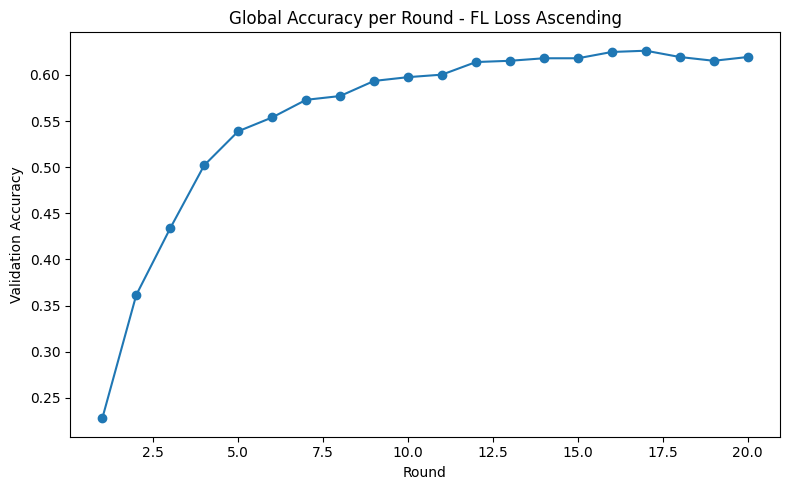

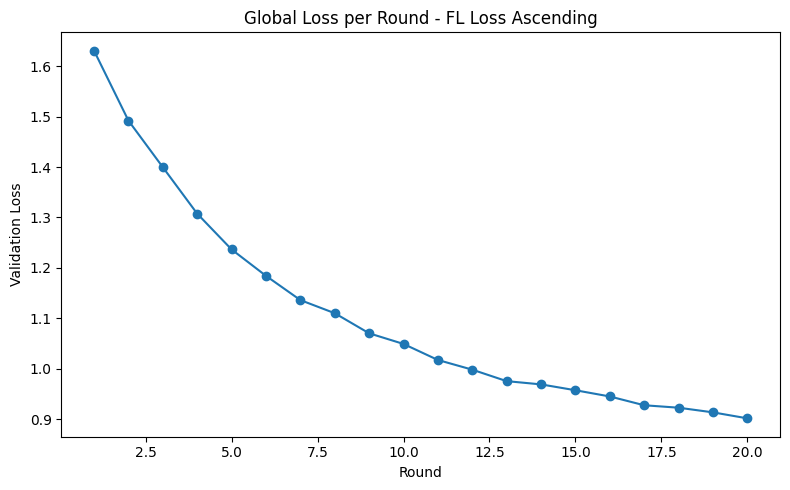

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/figures/global_accuracy_per_round.png
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/figures/global_loss_per_round.png


In [16]:
# =========================
# CELL 16 — PLOT GLOBAL ACCURACY / LOSS PER ROUND
# =========================
plt.figure(figsize=(8, 5))
plt.plot(round_history_df["round"], round_history_df["global_val_accuracy"], marker="o")
plt.xlabel("Round")
plt.ylabel("Validation Accuracy")
plt.title("Global Accuracy per Round - FL Loss Ascending")
plt.tight_layout()

acc_round_plot_path = os.path.join(FIGURES_DIR, "global_accuracy_per_round.png")
plt.savefig(acc_round_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
plt.plot(round_history_df["round"], round_history_df["global_val_loss"], marker="o")
plt.xlabel("Round")
plt.ylabel("Validation Loss")
plt.title("Global Loss per Round - FL Loss Ascending")
plt.tight_layout()

loss_round_plot_path = os.path.join(FIGURES_DIR, "global_loss_per_round.png")
plt.savefig(loss_round_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", acc_round_plot_path)
print("Saved:", loss_round_plot_path)

In [17]:
# =========================
# CELL 17 — FINAL EVALUATION ON GLOBAL VALIDATION SET
# =========================
final_eval = evaluate_model(global_model, val_ds, y_val)

y_true = final_eval["y_true"]
y_pred = final_eval["preds"]
y_prob = final_eval["probs"]

print("Final Validation Loss:", final_eval["loss"])
print("Final Validation Accuracy:", final_eval["accuracy"])

report_text = classification_report(y_true, y_pred, digits=4)
report_dict = classification_report(y_true, y_pred, digits=4, output_dict=True)

print("\nClassification Report:\n")
print(report_text)

report_txt_path = os.path.join(LOGS_DIR, "classification_report.txt")
report_json_path = os.path.join(LOGS_DIR, "classification_report.json")

with open(report_txt_path, "w") as f:
    f.write(report_text)

with open(report_json_path, "w") as f:
    json.dump(report_dict, f, indent=4)

print("Saved:", report_txt_path)
print("Saved:", report_json_path)

Final Validation Loss: 0.9277353882789612
Final Validation Accuracy: 0.6261937022209167

Classification Report:

              precision    recall  f1-score   support

           0     0.9242    0.9114    0.9177       361
           1     0.3022    0.5676    0.3944        74
           2     0.6023    0.2650    0.3681       200
           3     0.2073    0.4359    0.2810        39
           4     0.2647    0.3051    0.2835        59

    accuracy                         0.6262       733
   macro avg     0.4601    0.4970    0.4489       733
weighted avg     0.6823    0.6262    0.6300       733

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/classification_report.txt
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/classification_report.json


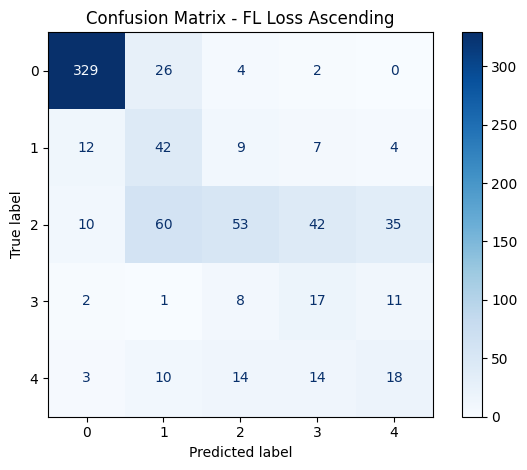

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/confusion_matrix_values.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/figures/confusion_matrix_fl_loss_asc.png
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/confusion_matrix_table.csv


In [18]:
# =========================
# CELL 18 — CONFUSION MATRIX + SAVE
# =========================
cm = confusion_matrix(y_true, y_pred)
cm_dict = {"confusion_matrix": cm.tolist()}

cm_json_path = os.path.join(LOGS_DIR, "confusion_matrix_values.json")
with open(cm_json_path, "w") as f:
    json.dump(cm_dict, f, indent=4)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(NUM_CLASSES))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - FL Loss Ascending")
plt.tight_layout()

cm_plot_path = os.path.join(FIGURES_DIR, "confusion_matrix_fl_loss_asc.png")
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{i}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{i}" for i in range(NUM_CLASSES)]
)
cm_csv_path = os.path.join(LOGS_DIR, "confusion_matrix_table.csv")
cm_df.to_csv(cm_csv_path)

print("Saved:", cm_json_path)
print("Saved:", cm_plot_path)
print("Saved:", cm_csv_path)

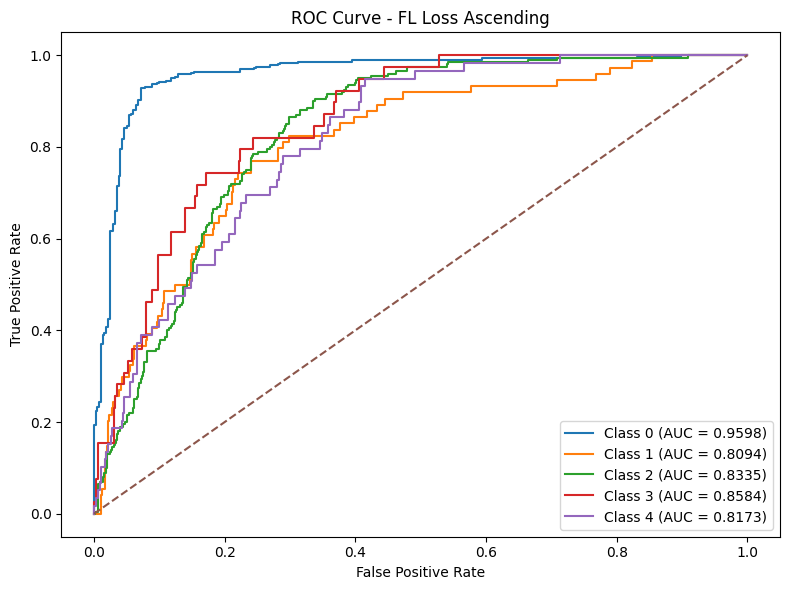

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/per_class_metrics.csv
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/per_class_metrics.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/figures/roc_curve_fl_loss_asc.png
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/roc_auc_per_class.json


In [19]:
# =========================
# CELL 19 — PER-CLASS METRICS + ROC CURVE
# =========================
precision_cls, recall_cls, f1_cls, support_cls = precision_recall_fscore_support(
    y_true, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0
)

per_class_df = pd.DataFrame({
    "class": np.arange(NUM_CLASSES),
    "precision": precision_cls,
    "recall": recall_cls,
    "f1_score": f1_cls,
    "support": support_cls
})

per_class_csv = os.path.join(LOGS_DIR, "per_class_metrics.csv")
per_class_json = os.path.join(LOGS_DIR, "per_class_metrics.json")
per_class_df.to_csv(per_class_csv, index=False)
per_class_df.to_json(per_class_json, orient="records", indent=4)

y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
roc_auc_per_class = {}

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    roc_auc_per_class[f"class_{i}"] = float(roc_auc_val)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_val:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - FL Loss Ascending")
plt.legend()
plt.tight_layout()

roc_curve_path = os.path.join(FIGURES_DIR, "roc_curve_fl_loss_asc.png")
plt.savefig(roc_curve_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

roc_auc_path = os.path.join(LOGS_DIR, "roc_auc_per_class.json")
with open(roc_auc_path, "w") as f:
    json.dump(roc_auc_per_class, f, indent=4)

print("Saved:", per_class_csv)
print("Saved:", per_class_json)
print("Saved:", roc_curve_path)
print("Saved:", roc_auc_path)

In [20]:
# =========================
# CELL 20 — SUMMARY METRICS TABLE
# =========================
acc = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)
auc_macro_ovr = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")

summary_metrics = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "method": "FL-only",
    "sequencing_strategy": SEQUENCING_STRATEGY,
    "global_val_accuracy": float(acc),
    "global_val_loss": float(final_eval["loss"]),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "precision_weighted": float(precision_weighted),
    "recall_weighted": float(recall_weighted),
    "f1_weighted": float(f1_weighted),
    "auc_macro_ovr": float(auc_macro_ovr),
    "auc_weighted_ovr": float(auc_weighted_ovr),
    "best_round_val_accuracy": float(round_history_df["global_val_accuracy"].max()),
    "best_round_val_loss": float(round_history_df["global_val_loss"].min())
}

summary_metrics_path = os.path.join(LOGS_DIR, "summary_metrics.json")
with open(summary_metrics_path, "w") as f:
    json.dump(summary_metrics, f, indent=4)

summary_df = pd.DataFrame([summary_metrics])
summary_csv_path = os.path.join(LOGS_DIR, "baseline_comparison_ready_table.csv")
summary_df.to_csv(summary_csv_path, index=False)

display(summary_df)

print("Saved:", summary_metrics_path)
print("Saved:", summary_csv_path)

,experiment_name,model_name,method,sequencing_strategy,global_val_accuracy,global_val_loss,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_macro_ovr,auc_weighted_ovr,best_round_val_accuracy,best_round_val_loss
0,exp2_fl_loss_asc,mobilenet,FL-only,loss_ascending,0.626194,0.927735,0.460122,0.496981,0.448918,0.682317,0.626194,0.629975,0.855686,0.893311,0.626194,0.901802


Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/summary_metrics.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/baseline_comparison_ready_table.csv


,client_id,avg_train_loss,avg_train_accuracy,total_samples,total_rounds_participated,avg_elapsed_seconds
0,0,1.446209,0.514739,977,20,33.288633
1,1,1.431425,0.517469,976,20,33.189479
2,2,1.438705,0.496773,976,20,33.153266


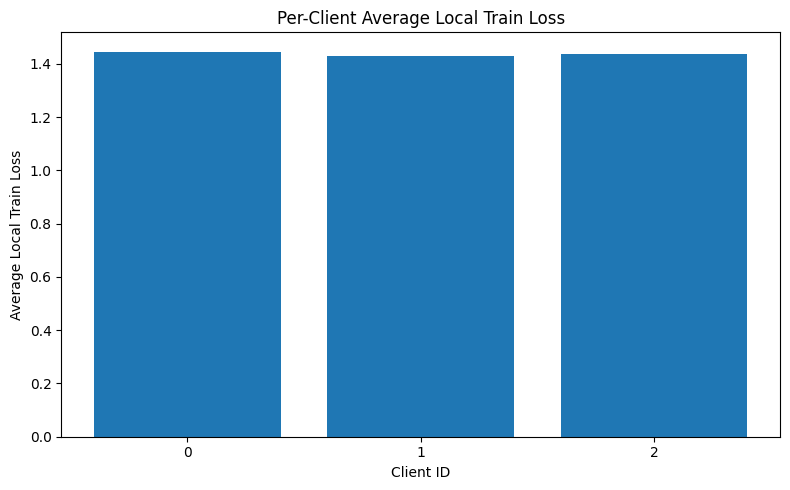

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/per_client_performance.csv
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/figures/per_client_avg_train_loss.png


In [21]:
# =========================
# CELL 21 — PER-CLIENT PERFORMANCE TABLE
# =========================
per_client_perf_df = client_round_logs_df.groupby("client_id").agg(
    avg_train_loss=("train_loss", "mean"),
    avg_train_accuracy=("train_accuracy", "mean"),
    total_samples=("num_samples", "first"),
    total_rounds_participated=("round", "count"),
    avg_elapsed_seconds=("elapsed_seconds", "mean")
).reset_index()

per_client_csv = os.path.join(LOGS_DIR, "per_client_performance.csv")
per_client_perf_df.to_csv(per_client_csv, index=False)

display(per_client_perf_df)

plt.figure(figsize=(8, 5))
plt.bar(per_client_perf_df["client_id"].astype(str), per_client_perf_df["avg_train_loss"])
plt.xlabel("Client ID")
plt.ylabel("Average Local Train Loss")
plt.title("Per-Client Average Local Train Loss")
plt.tight_layout()

per_client_loss_plot = os.path.join(FIGURES_DIR, "per_client_avg_train_loss.png")
plt.savefig(per_client_loss_plot, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", per_client_csv)
print("Saved:", per_client_loss_plot)

In [22]:
# =========================
# CELL 22 — COMMUNICATION COST ANALYSIS
# =========================
model_size_mb = estimate_model_size_mb(global_model)

# rough estimate:
# each client downloads global model once per round
# each client uploads local model once per round
download_mb_total = NUM_CLIENTS * NUM_ROUNDS * model_size_mb
upload_mb_total = NUM_CLIENTS * NUM_ROUNDS * model_size_mb
total_comm_mb = download_mb_total + upload_mb_total

comm_summary = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "num_clients": int(NUM_CLIENTS),
    "num_rounds": int(NUM_ROUNDS),
    "local_epochs": int(LOCAL_EPOCHS),
    "estimated_model_size_mb": float(model_size_mb),
    "estimated_total_download_mb": float(download_mb_total),
    "estimated_total_upload_mb": float(upload_mb_total),
    "estimated_total_communication_mb": float(total_comm_mb),
    "avg_round_train_time_sec": float(round_history_df["round_total_local_train_time_sec"].mean())
}

comm_summary_path = os.path.join(LOGS_DIR, "communication_cost_summary.json")
with open(comm_summary_path, "w") as f:
    json.dump(comm_summary, f, indent=4)

print(json.dumps(comm_summary, indent=4))
print("Saved:", comm_summary_path)

{
    "experiment_name": "exp2_fl_loss_asc",
    "model_name": "mobilenet",
    "num_clients": 3,
    "num_rounds": 20,
    "local_epochs": 1,
    "estimated_model_size_mb": 8.637958526611328,
    "estimated_total_download_mb": 518.2775115966797,
    "estimated_total_upload_mb": 518.2775115966797,
    "estimated_total_communication_mb": 1036.5550231933594,
    "avg_round_train_time_sec": 99.63137789964676
}
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/communication_cost_summary.json


In [23]:
# =========================
# CELL 23 — SAVE FINAL MODEL
# =========================
FINAL_MODEL_PATH = os.path.join(MODELS_DIR, "mobilenet_fl_loss_asc_final.keras")
global_model.save(FINAL_MODEL_PATH)

print("Model saved to:", FINAL_MODEL_PATH)

Model saved to: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/models/mobilenet_fl_loss_asc_final.keras


In [24]:
# =========================
# CELL 24 — SAVE RUN INFO + COMPARISON READY FILE
# =========================
run_info = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": MODEL_NAME,
    "method": "FL-only",
    "sequencing_strategy": SEQUENCING_STRATEGY,
    "npz_path": NPZ_PATH,
    "seed": SEED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES,
    "split_type": "global_train_val_split",
    "train_ratio": 0.8,
    "val_ratio": 0.2,
    "train_size": int(len(X_train)),
    "val_size": int(len(X_val)),
    "num_clients": int(NUM_CLIENTS),
    "num_rounds": int(NUM_ROUNDS),
    "local_epochs": int(LOCAL_EPOCHS),
    "local_lr": float(LOCAL_LR),
    "optimizer": OPTIMIZER_NAME,
    "loss_function": LOSS_FUNCTION,
    "artifacts": {
        "final_model_path": FINAL_MODEL_PATH,
        "round_history_json": os.path.join(LOGS_DIR, "round_history.json"),
        "round_metrics_csv": os.path.join(LOGS_DIR, "round_metrics.csv"),
        "client_round_logs_json": os.path.join(LOGS_DIR, "client_round_logs.json"),
        "client_round_logs_csv": os.path.join(LOGS_DIR, "client_round_logs.csv"),
        "classification_report_txt": os.path.join(LOGS_DIR, "classification_report.txt"),
        "classification_report_json": os.path.join(LOGS_DIR, "classification_report.json"),
        "confusion_matrix_values": os.path.join(LOGS_DIR, "confusion_matrix_values.json"),
        "per_class_metrics_csv": os.path.join(LOGS_DIR, "per_class_metrics.csv"),
        "per_class_metrics_json": os.path.join(LOGS_DIR, "per_class_metrics.json"),
        "summary_metrics": os.path.join(LOGS_DIR, "summary_metrics.json"),
        "communication_cost_summary": os.path.join(LOGS_DIR, "communication_cost_summary.json"),
        "client_data_summary": os.path.join(LOGS_DIR, "client_data_summary.json"),
        "global_accuracy_per_round": os.path.join(FIGURES_DIR, "global_accuracy_per_round.png"),
        "global_loss_per_round": os.path.join(FIGURES_DIR, "global_loss_per_round.png"),
        "confusion_matrix_figure": os.path.join(FIGURES_DIR, "confusion_matrix_fl_loss_asc.png"),
        "roc_curve_figure": os.path.join(FIGURES_DIR, "roc_curve_fl_loss_asc.png")
    }
}

run_info_path = os.path.join(LOGS_DIR, "mobilenet_fl_loss_asc_run_info.json")
with open(run_info_path, "w") as f:
    json.dump(run_info, f, indent=4)

comparison_ready = {
    "method": "FL-only",
    "variant": "loss_ascending",
    "model": MODEL_NAME,
    "accuracy": float(acc),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "auc_macro_ovr": float(auc_macro_ovr),
    "num_rounds": int(NUM_ROUNDS),
    "num_clients": int(NUM_CLIENTS),
    "notes": "Global 80:20 split; FL-only with loss ascending client sequence"
}

comparison_ready_path = os.path.join(LOGS_DIR, "comparison_ready_fl_loss_asc.json")
with open(comparison_ready_path, "w") as f:
    json.dump(comparison_ready, f, indent=4)

print("Saved:", run_info_path)
print("Saved:", comparison_ready_path)

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/mobilenet_fl_loss_asc_run_info.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp2_fl_loss_asc/mobilenet/logs/comparison_ready_fl_loss_asc.json


In [25]:
# =========================
# CELL 25 — QUICK RESULT SUMMARY
# =========================
with open(os.path.join(LOGS_DIR, "summary_metrics.json"), "r") as f:
    metrics = json.load(f)

print(json.dumps(metrics, indent=4))

{
    "experiment_name": "exp2_fl_loss_asc",
    "model_name": "mobilenet",
    "method": "FL-only",
    "sequencing_strategy": "loss_ascending",
    "global_val_accuracy": 0.626193724420191,
    "global_val_loss": 0.9277353882789612,
    "precision_macro": 0.46012225190969636,
    "recall_macro": 0.4969814179895874,
    "f1_macro": 0.44891814939524943,
    "precision_weighted": 0.6823165854216879,
    "recall_weighted": 0.626193724420191,
    "f1_weighted": 0.629974868440461,
    "auc_macro_ovr": 0.8556855360229099,
    "auc_weighted_ovr": 0.8933109708968191,
    "best_round_val_accuracy": 0.6261937022209167,
    "best_round_val_loss": 0.9018022418022156
}
